<a href="https://colab.research.google.com/github/PrishitaM/K-means_Clustering_Full_Project/blob/main/K_Means_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

### Business Context
RankForYou is a higher‑education ranking and insights agency that helps students, parents, and recruiters make informed college choices. This year, the agency wants to publish an evidence‑based editorial on the state of engineering education in the country, using its annual survey of 26 engineering colleges.

Despite having rich survey data on teaching quality, fees, placements, internships, and infrastructure, RankForYou currently lacks a clear segmentation of colleges. Without this, its rankings and public communication risk being generic, less trustworthy, and less useful for students, colleges, and corporates.

The key business need is to identify distinct “types” of engineering colleges and articulate how they differ in value delivered to students (outcomes vs cost). If this is not done now, the upcoming editorial will be opinion‑driven rather than data‑driven, weakening RankForYou’s credibility and competitive position in the ranking space.

### Objective
The objective is to use the 26‑college survey dataset to segment engineering colleges into meaningful clusters based on teaching quality, fees, placements, internships, and infrastructure, and to derive actionable insights for RankForYou’s upcoming editorial and stakeholder recommendations.

Specifically, we aim to:
* Determine how many distinct clusters (types) of engineering colleges can be identified from the data.
* Characterize each cluster in terms of cost (fees) versus outcomes (teaching, placements, internships, infrastructure).
* Compare clustering techniques (e.g., k‑means vs hierarchical) and explain any differences in the resulting segments.
* Translate these segments into clear narratives and recommendations for:
    * Students and parents (which types of colleges offer better value)
    * Corporates (which clusters to prioritize for hiring/internships)
    * Colleges (what to improve to move into higher‑performing clusters)

### Data Description

The data contains survey results for 26 engineering colleges. The initial survey data has been summarized into a rating scale of 1‑5 for different factors.

**Factor rating index**
 - 1 - Very low
 - 2 - Low
 - 3 - Medium
 - 4 - High
 - 5 - Very high

**Data Dictionary**
 - SR_NO: Serial Number
 - Engg_College: 26 Engineering colleges with pseudonyms A to Z
 - Teaching: Quality of teaching at the engineering college
 - Fees: Fees at the engineering college
 - Placements: Job placements after a student graduates from the engineering college
 - Internship: Student Internships at the engineering college
 - Infrastructure: Infrastructure of the engineering college

# **Importing Necessary Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# **Data Loading**

In [2]:
data = pd.read_csv("/content/Engineering Colleges Case Study.csv")

# **Data Overview**

The initial steps to get an overview of any dataset is to:
- observe the first few rows of the dataset, to check whether the dataset has been loaded properly or not
- get information about the number of rows and columns in the dataset
- find out the data types of the columns to ensure that data is stored in the preferred format and the value of each property is as expected.
- check the statistical summary of the dataset to get an overview of the numerical columns of the data

### View the first and last few rows of the dataset

In [3]:
data.head()

,SR_NO,Engg_College,Teaching,Fees,Placements,Internship,Infrastructure
0,1,A,5,2,5,5,3
1,2,B,4,2,5,5,3
2,3,C,4,5,5,4,5
3,4,D,5,4,5,4,4
4,5,E,2,5,2,2,5


In [4]:
data.tail()

,SR_NO,Engg_College,Teaching,Fees,Placements,Internship,Infrastructure
21,22,V,2,2,1,2,1
22,23,W,2,5,1,1,1
23,24,X,1,1,1,2,5
24,25,Y,1,1,1,1,5
25,26,Z,3,4,5,2,3


### Understand the shape of the dataset

In [5]:
data.shape

(26, 7)

The dataset has 26 rows and 7 columns

### Check the data types of the columns for the dataset

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   SR_NO           26 non-null     int64 
 1   Engg_College    26 non-null     object
 2   Teaching        26 non-null     int64 
 3   Fees            26 non-null     int64 
 4   Placements      26 non-null     int64 
 5   Internship      26 non-null     int64 
 6   Infrastructure  26 non-null     int64 
dtypes: int64(6), object(1)
memory usage: 1.6+ KB


### Checking for duplicate values

In [7]:
data.duplicated().sum()

np.int64(0)

- There are no duplicate values in the dataset.

### Checking for missing values

In [8]:
data.isnull().sum()

,0
SR_NO,0
Engg_College,0
Teaching,0
Fees,0
Placements,0
Internship,0
Infrastructure,0


- There are no missing values in the dataset

### Statistical summary

In [9]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
SR_NO,26.0,13.500000,7.648529,1.0,7.25,13.5,19.75,26.0
Teaching,26.0,2.807692,1.132051,1.0,2.00,3.0,3.00,5.0
Fees,26.0,3.576923,1.331858,1.0,2.25,4.0,5.00,5.0
Placements,26.0,2.884615,1.531716,1.0,1.25,3.0,4.00,5.0
Internship,26.0,2.769231,1.242826,1.0,2.00,2.0,4.00,5.0
Infrastructure,26.0,3.384615,1.298520,1.0,3.00,3.0,4.75,5.0


**Observations**

- The median value of fees is 4, indicating that most of the engineering colleges have high fees.
- The mean and median of other ratings lie between 2 and 3, except the mean infrastructure rating.

# **Exploratory Data Analysis (EDA)**

### Creating a copy of original data

In [10]:
df = data.copy()
df.drop("SR_NO", axis=1, inplace=True)

## Univariate Analysis

### Distribution of `Teaching`

/tmp/ipykernel_718/3462471244.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Teaching", palette="Paired")


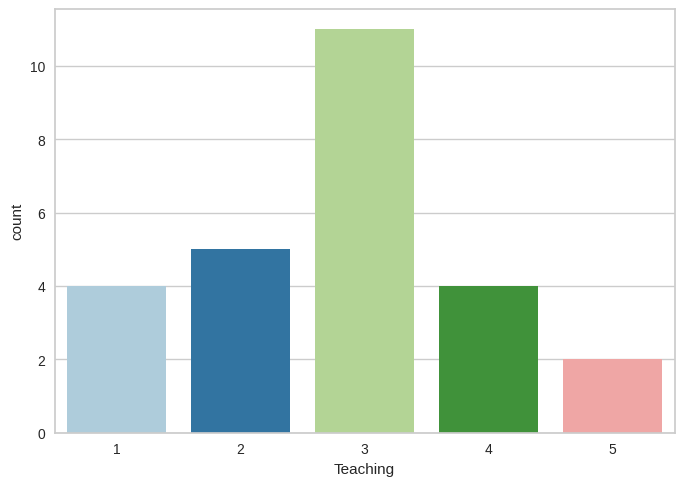

In [11]:
sns.countplot(data=df, x="Teaching", palette="Paired")
plt.show()

Teaching ratings are approximately normally distributed around the middle of the scale.

### Distribution of `Fees`

/tmp/ipykernel_718/3934848452.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Fees", palette="Paired")


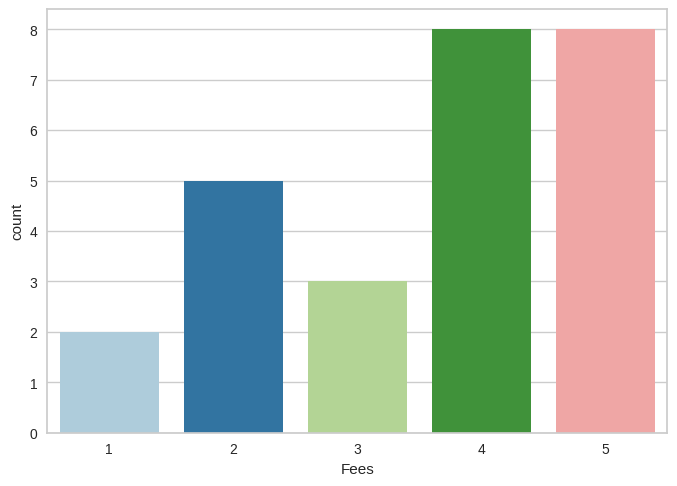

In [12]:
sns.countplot(data=df, x="Fees", palette="Paired")
plt.show()

Fees ratings show a bimodal pattern, indicating two distinct groups of colleges based on fee levels.

### Distribution of `Placements`

/tmp/ipykernel_718/2517105621.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Placements", palette="Paired")


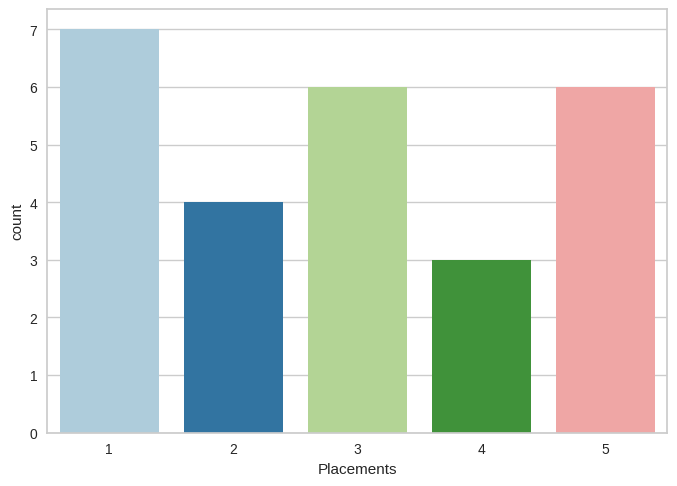

In [13]:
sns.countplot(data=df, x="Placements", palette="Paired")
plt.show()

Over 85% of colleges have placement ratings below 4, with maximum percentage of placements for college rated at 1.

### Distribution of `Internship`

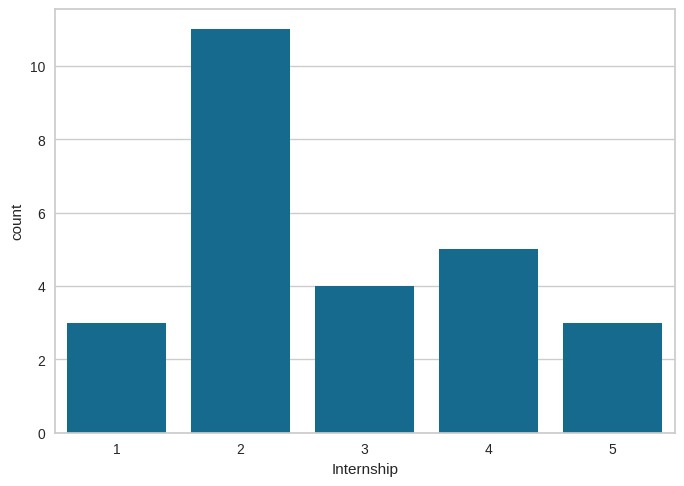

In [15]:
sns.countplot(data=df, x="Internship")
plt.show()

Internship ratings are also bimodal, suggesting a clear split between colleges with poor and good internship opportunities.

### Distribution of `Infrastructure`

/tmp/ipykernel_718/210990347.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Infrastructure", palette="Paired")


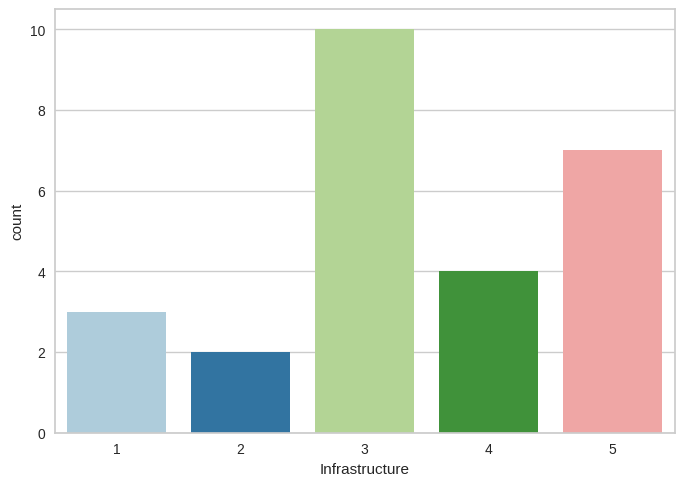

In [16]:
sns.countplot(data=df, x="Infrastructure", palette="Paired")
plt.show()

More than 80% of the colleges have a rating of 3 or more for infrastructure.

## Bivariate Analysis

### Correlation Check

In [17]:
num_col = ["Teaching", "Fees", "Placements", "Internship", "Infrastructure"]

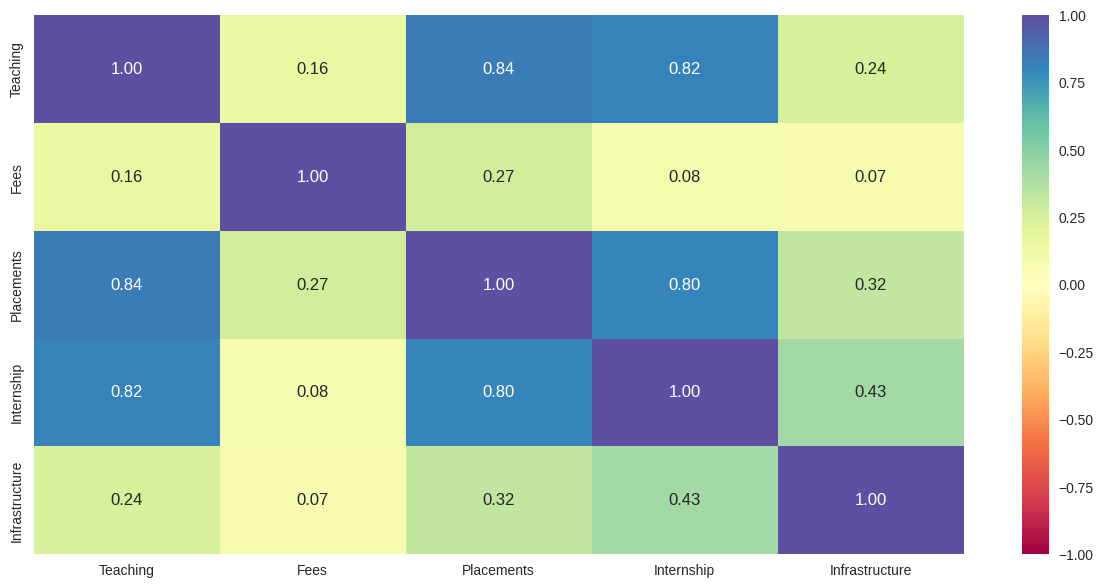

In [18]:
plt.figure(figsize=(15, 7))
sns.heatmap(df[num_col].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

**Observation**

- Rating for teaching is strongly positively correlated with the rating for placements and internships.
- This is aligned with general observations that teaching quality is high, students are more likely to get placements and internships.

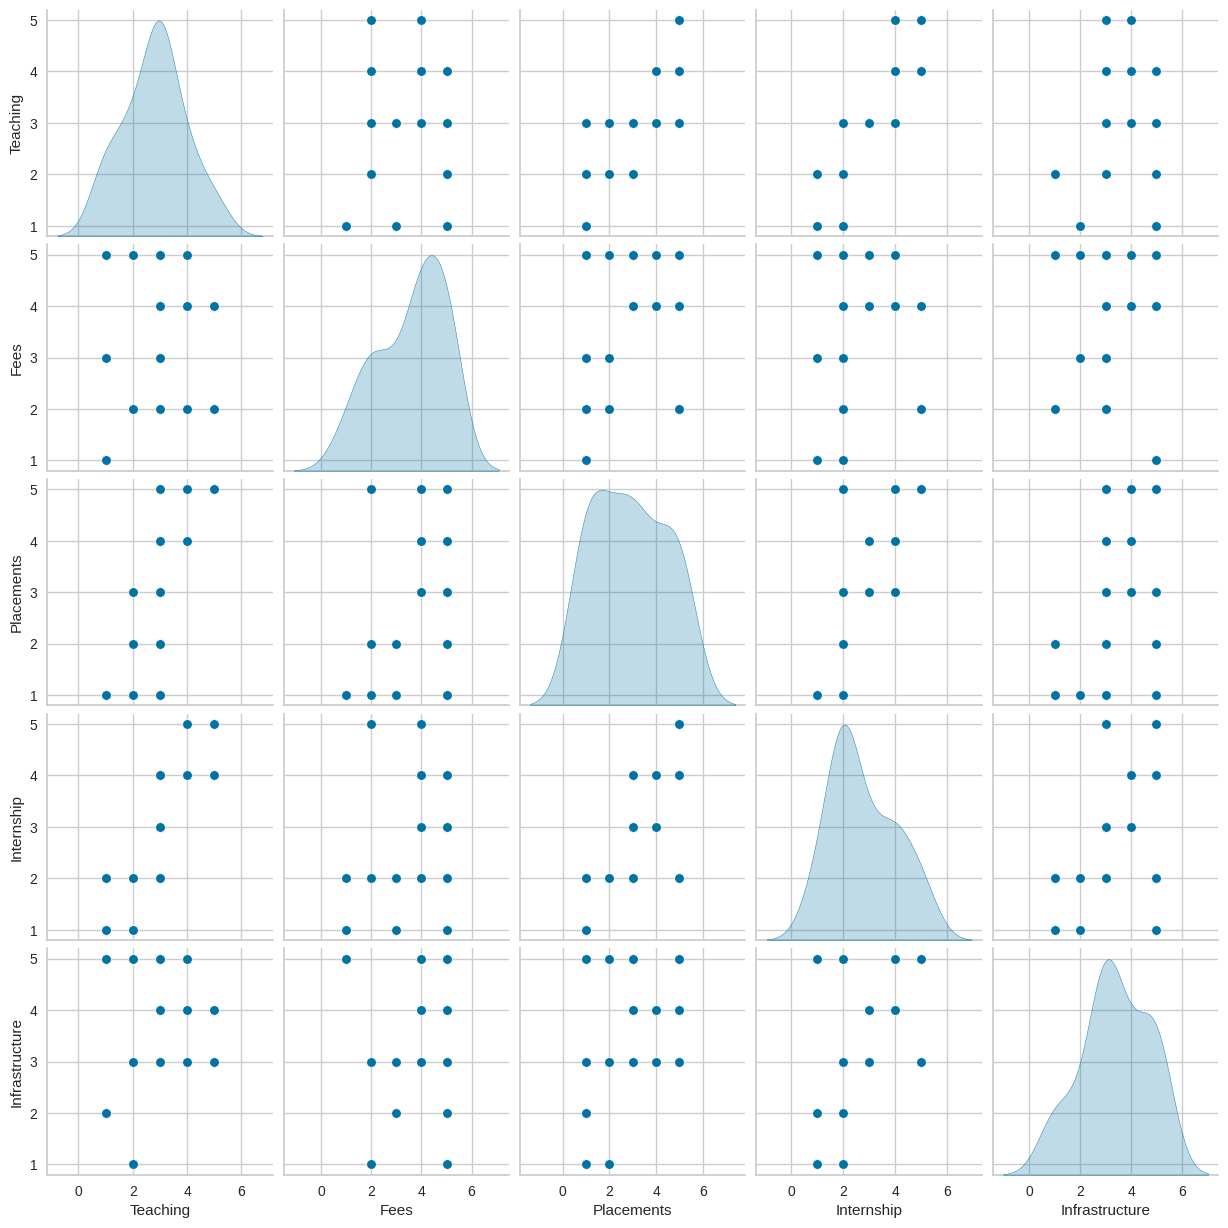

In [19]:
sns.pairplot(data=df[num_col], diag_kind="kde")
plt.show()

**Observations**

- The dominant structure in the correlation matrix is an “academic–outcome block”: Teaching, Placements, and Internship are tightly linked and move together.
- Infrastructure plays a secondary supportive role.
- Fees behave more independently, reflecting pricing strategies that are not always aligned with delivered academic and career outcomes.

### `Teaching` vs `Placements`

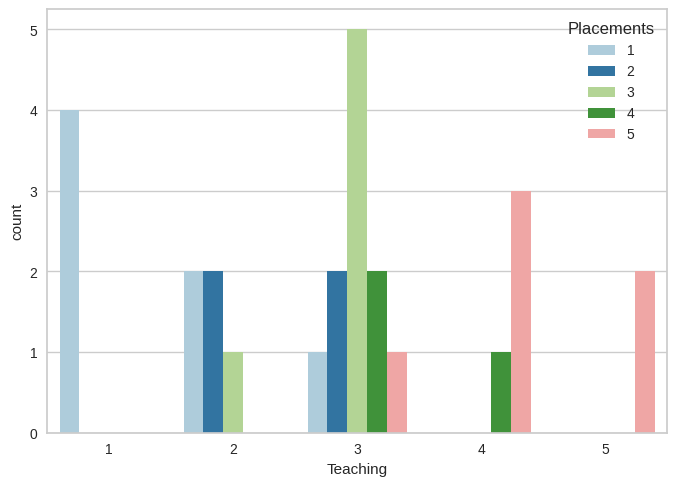

In [20]:
sns.countplot(data=df, x="Teaching", hue="Placements", palette="Paired")
plt.show()

Colleges with higher teaching ratings tend to have higher placement ratings.
This suggests that better teaching quality directly contributes to students being more employable and attractive to recruiters.

### `Teaching` vs `Internship`

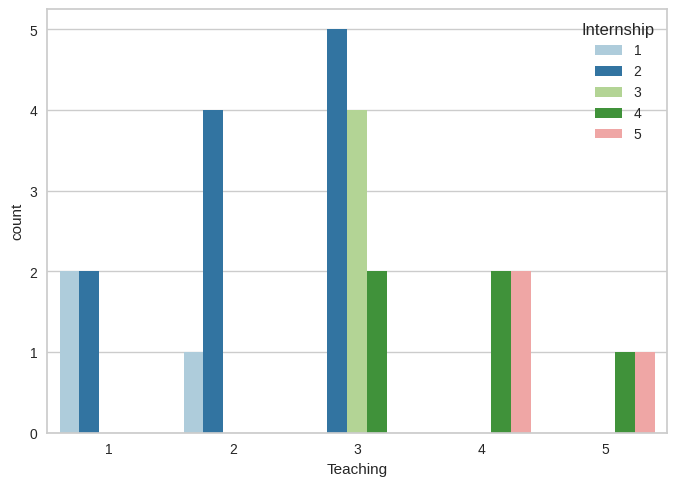

In [21]:
sns.countplot(data=df, x="Teaching", hue="Internship", palette="Paired")
plt.show()

Higher teaching ratings are also strongly associated with higher internship ratings. Strong academics likely help students clear internship selection processes and perform better during internships.

### `Placements` vs `Internship`

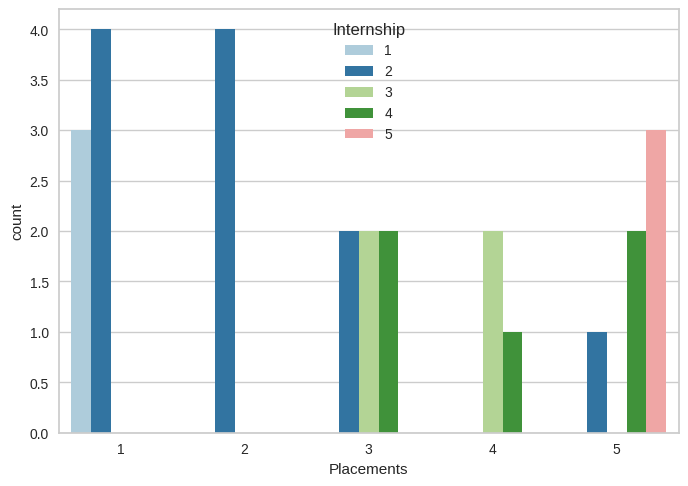

In [22]:
sns.countplot(data=df, x="Placements", hue="Internship", palette="Paired")
plt.show()

Colleges that offer good internships also tend to have better placements.
Internships appear to act as a bridge to final job offers, indicating that early industry exposure improves final employment outcomes.

### `Infrastructure` vs `Teaching`

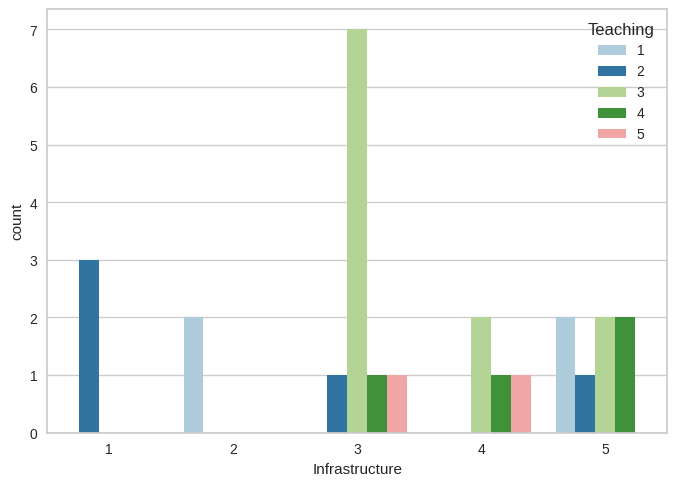

In [23]:
sns.countplot(data=df, x="Infrastructure", hue="Teaching", palette="Paired")
plt.show()

Better infrastructure is somewhat associated with better teaching, but the relationship is not as strong as with placements and internships.
Good facilities may support better teaching (labs, classrooms, equipment), but infrastructure alone does not guarantee high academic quality.

# **Data Preprocessing**

In [24]:
scaler = StandardScaler()
subset = df[num_col].copy()
subset_scaled = scaler.fit_transform(subset)
subset_scaled_df = pd.DataFrame(subset_scaled, columns=subset.columns)

# **K-means Clustering**

## Model Building and Evaluation for Different "K"

### Elbow Method

Number of Clusters: 1 	Inertia: 130.00000000000003
Number of Clusters: 2 	Inertia: 75.04213481944873
Number of Clusters: 3 	Inertia: 54.390859690231764
Number of Clusters: 4 	Inertia: 48.199297215040495
Number of Clusters: 5 	Inertia: 33.27114661150165
Number of Clusters: 6 	Inertia: 26.354029809700442
Number of Clusters: 7 	Inertia: 21.221807524933304
Number of Clusters: 8 	Inertia: 16.054981173463535


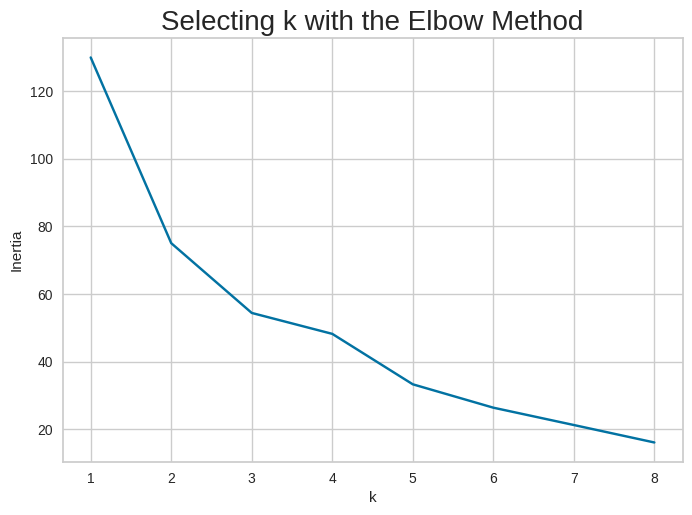

In [25]:
clusters = range(1, 9)
inertias = []

for k in clusters:
    model = KMeans(n_clusters=k, random_state=1)
    model.fit(subset_scaled_df)
    inertias.append(model.inertia_)
    print("Number of Clusters:", k, "\tInertia:", model.inertia_)

plt.plot(clusters, inertias, "bx-")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Selecting k with the Elbow Method", fontsize=20)
plt.show()

**The appropriate value of k from the elbow curve seems to be 4 or 5.**

### Silhouette Score

For n_clusters = 2, silhouette score is 0.34077941058708244
For n_clusters = 3, silhouette score is 0.32008415295181053
For n_clusters = 4, silhouette score is 0.28712962659404895
For n_clusters = 5, silhouette score is 0.3131121267536491
For n_clusters = 6, silhouette score is 0.3051626087709657
For n_clusters = 7, silhouette score is 0.3152029547319533
For n_clusters = 8, silhouette score is 0.39889060738670234
For n_clusters = 9, silhouette score is 0.39893490104217144


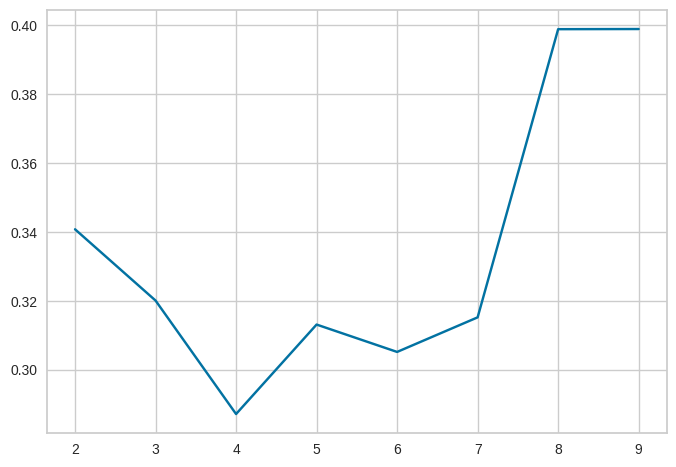

In [26]:
sil_score = []
cluster_list = list(range(2, 10))
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters)
    preds = clusterer.fit_predict(subset_scaled_df)
    score = silhouette_score(subset_scaled_df, preds)
    sil_score.append(score)
    print("For n_clusters = {}, silhouette score is {}".format(n_clusters, score))

plt.plot(cluster_list, sil_score)
plt.show()

**The silhouette curve shows initial peaks at k=3, k=5, and k=7, and then goes higher, indicating that while the main data structure is captured within 7 clusters, additional clusters might offer more separability.**

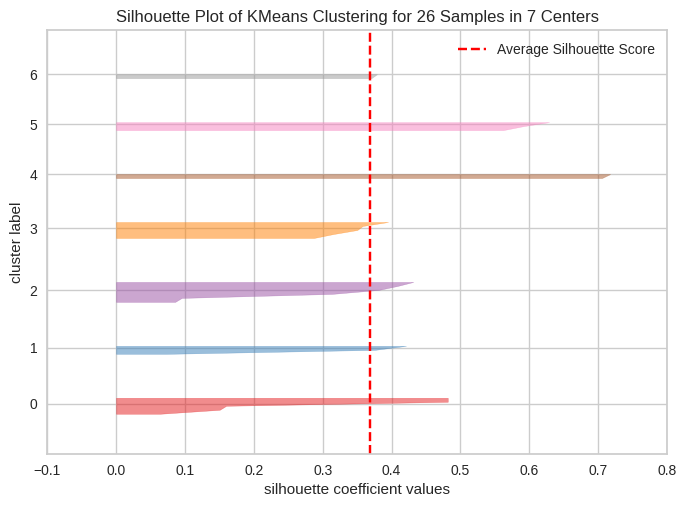

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 26 Samples in 7 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [27]:
visualizer = SilhouetteVisualizer(KMeans(7, random_state=1))
visualizer.fit(subset_scaled_df)
visualizer.show()

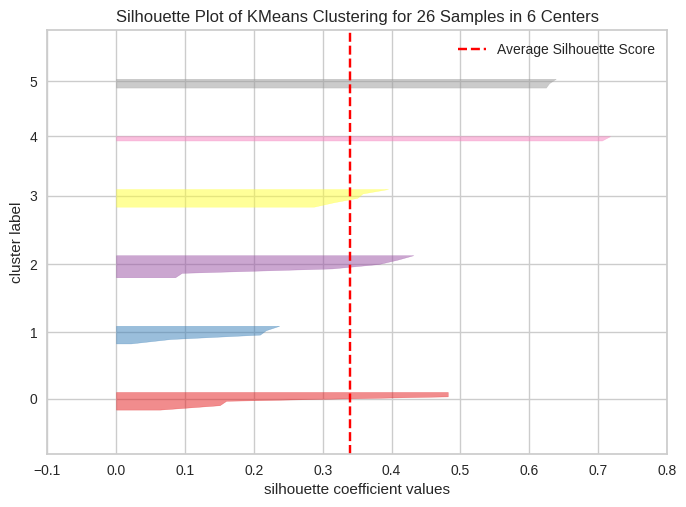

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 26 Samples in 6 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [28]:
visualizer = SilhouetteVisualizer(KMeans(6, random_state=1))
visualizer.fit(subset_scaled_df)
visualizer.show()

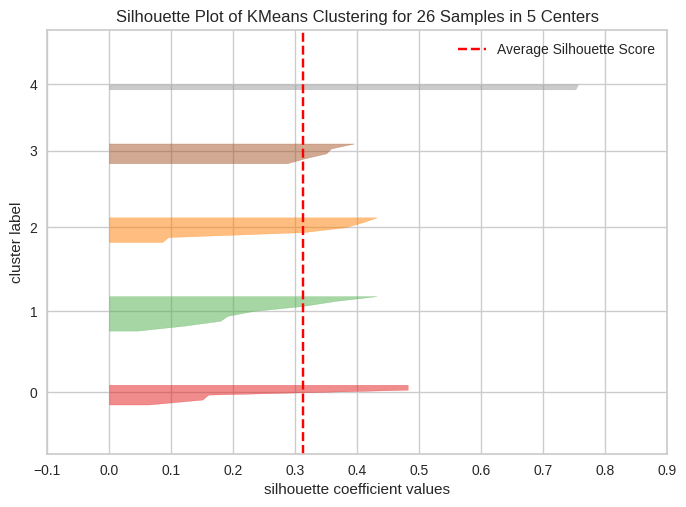

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 26 Samples in 5 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [29]:
visualizer = SilhouetteVisualizer(KMeans(5, random_state=1))
visualizer.fit(subset_scaled_df)
visualizer.show()

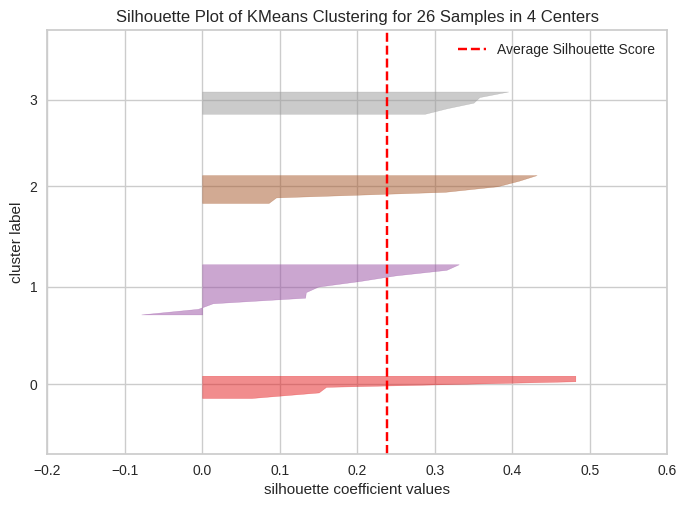

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 26 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [30]:
visualizer = SilhouetteVisualizer(KMeans(4, random_state=1))
visualizer.fit(subset_scaled_df)
visualizer.show()

Here K = 5 strikes the best balance for the data provided:

- **Highest Average Silhouette:** At K=5 the red dashed line sits highest (0.32), outperforming K=4 (0.24), and K=6 (0.33) only marginally higher at K=6 but at the cost of smaller, less stable clusters.

- **Well-Separated, Cohesive Clusters:** All five violins at K=5 lie mostly to the right of zero with tight, tall shapes - indicating each cluster's members are much closer to their own centroid than to others.

- **Avoids Overfitting & Tiny Clusters:** Beyond K=5, you begin to see very small clusters with few samples (e.g. K=7) or some negative silhouettes, suggesting misleading splits rather than meaningful groupings.

- **Interpretability & Practicality:** Five clusters give clear, distinguishable segments that align well with downstream profiling, without overwhelming complexity or diluting sample sizes.

## Final Model Selection

**Let's take 5 as the appropriate no. of clusters as the silhouette score is high enough and there is knick at 5 in the elbow curve.**

In [31]:
final_model = KMeans(n_clusters=5, random_state=0)
final_model.fit(subset_scaled_df)
df["K_means_segments"] = final_model.labels_

# **Cluster Profiling**

In [32]:
cluster_profile = df.drop("Engg_College", axis=1).groupby("K_means_segments").mean()
cluster_profile["count_in_each_segment"] = df.groupby("K_means_segments")["Fees"].count().values
cluster_profile.style.highlight_max(color="lightgreen", axis=0)

,Teaching,Fees,Placements,Internship,Infrastructure,count_in_each_segment
K_means_segments,,,,,,
0,2.333333,2.500000,1.500000,1.833333,2.166667,6
1,3.000000,4.500000,3.666667,2.666667,3.333333,6
2,4.000000,3.625000,4.375000,4.375000,4.250000,8
3,1.750000,5.000000,1.750000,1.750000,2.750000,4
4,1.000000,1.000000,1.000000,1.500000,5.000000,2


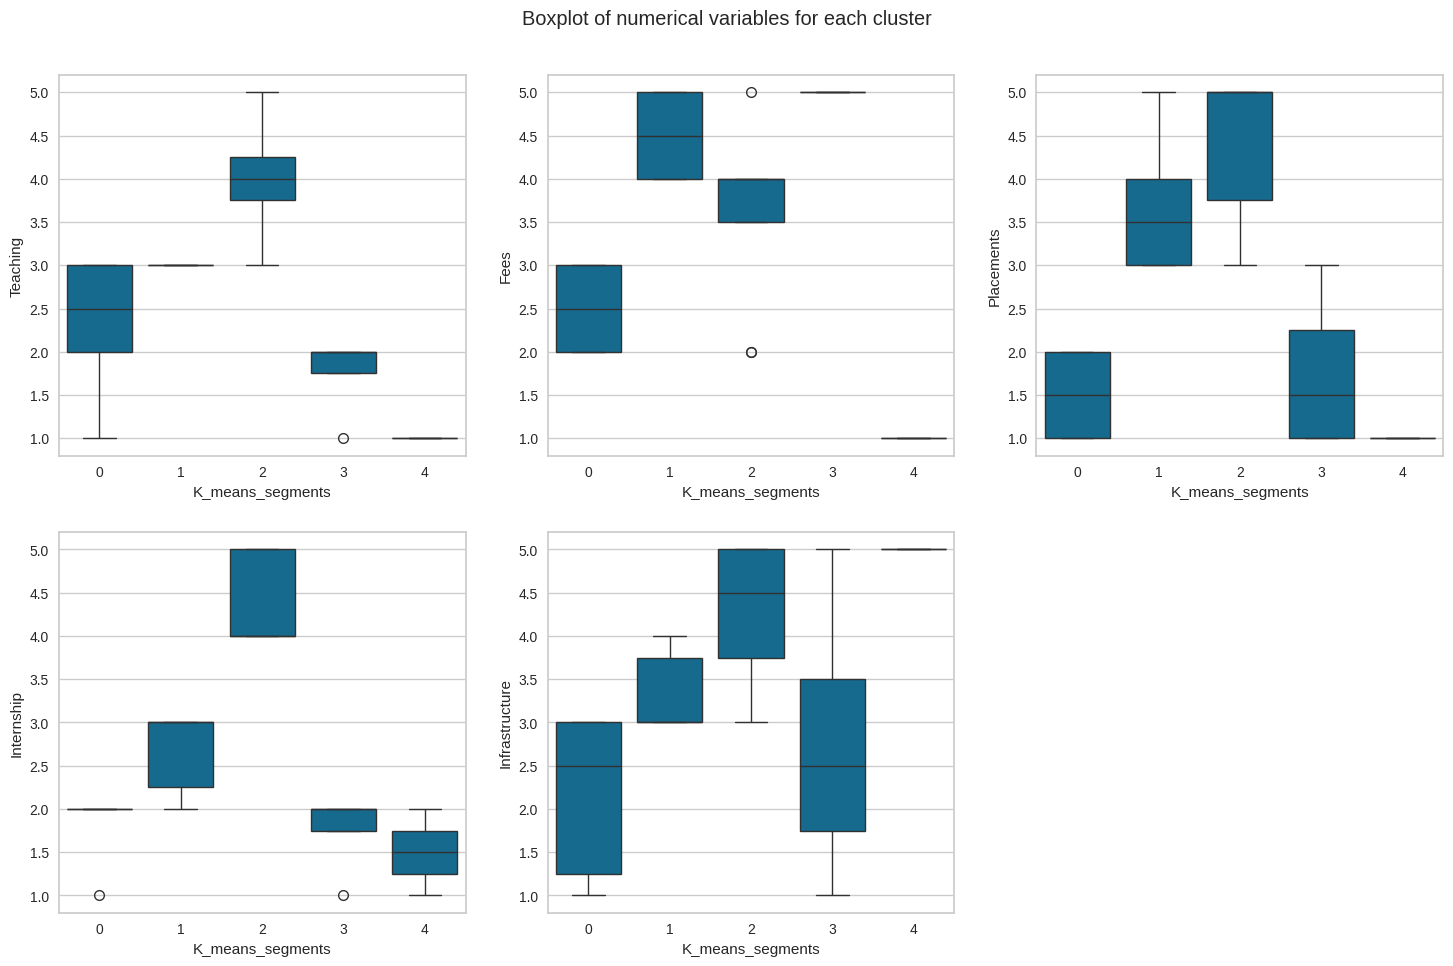

In [33]:
plt.figure(figsize=(15, 10))
plt.suptitle("Boxplot of numerical variables for each cluster")

for i, variable in enumerate(num_col):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(data=df, x="K_means_segments", y=variable)

plt.tight_layout(pad=2.0)
plt.show()

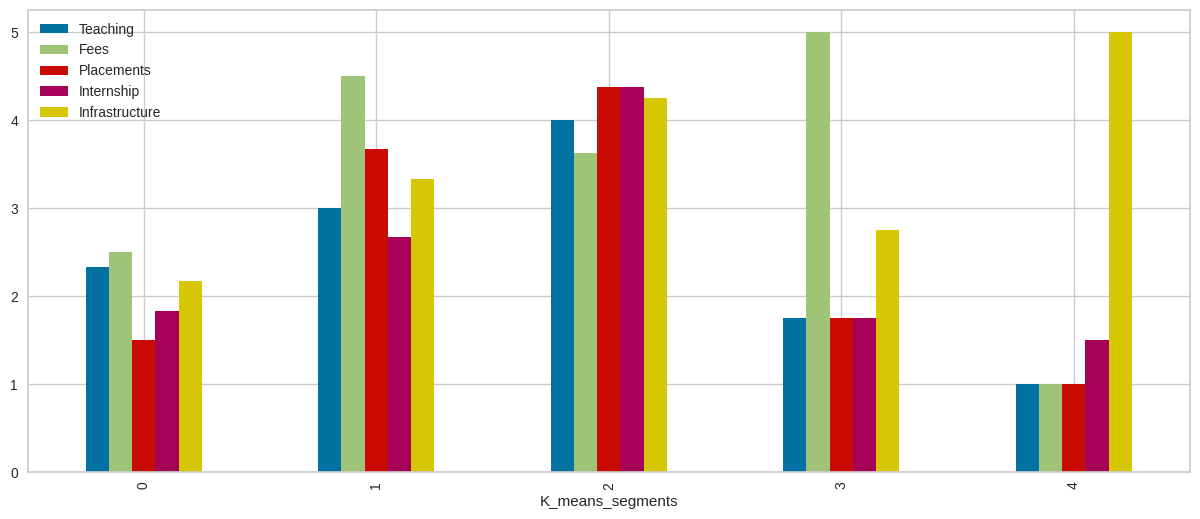

In [34]:
df.drop("Engg_College", axis=1).groupby("K_means_segments").mean().plot.bar(figsize=(15, 6))
plt.show()

### Observations

- **Cluster 0**:
    - Teaching: Moderate to slightly high (median around 2.8–3).
    - Fees: High to very high.
    - Placements: Moderate (median ~3), with slight spread.
    - Internship: Moderate to high.
    - Infrastructure: High to very high (mostly around 4.5).
    - **Summary:** Colleges in Cluster 0 offer good infrastructure and internship opportunities with reasonably high fees and moderate teaching and placements.

- **Cluster 1**:
    - Teaching: Low to moderate (median ~2), with a wider spread.
    - Fees: Moderate (median ~3.2), but with a wide range from low to high.
    - Placements: Very low (median ~1.5).
    - Internship: Low to moderate.
    - Infrastructure: Low to moderate (median ~2), with high variability.
    - **Summary:** Cluster 1 includes colleges with poor placement and internship opportunities, average fees, and variable ratings in other aspects.

- **Cluster 2**:
    - Teaching: Very high (median ~4.5 to 5).
    - Fees: Moderate to high.
    - Placements: Very high (median ~4.8–5).
    - Internship: Very high.
    - Infrastructure: High to very high.
    - **Summary:** Cluster 2 represents top-performing colleges across almost all aspects—especially in teaching, placements, and internships.

- **Cluster 3**:
    - Teaching: Moderate (median ~3), with little variability.
    - Fees: High (median ~4.5).
    - Placements: High (median ~4).
    - Internship: Low to moderate.
    - Infrastructure: Moderate (median ~3).
    - **Summary:** Cluster 3 colleges charge higher fees and offer good placements but are average in other aspects.

- **Cluster 4**:
    - Teaching: Very low (mostly 1).
    - Fees: Very low (uniformly 1).
    - Placements: Very low (uniformly 1).
    - Internship: Very low.
    - Infrastructure: Very high (uniformly 5).
    - **Summary:** Cluster 4 is unique—colleges in this group offer excellent infrastructure but are significantly weak in all other dimensions.

# **Conclusions and Business Recommendations**

### Conclusions

* **Cluster 0 (Tier 2 colleges):**
Colleges in this cluster show moderate teaching quality and infrastructure but weaker placements and internship opportunities. Fees are generally moderate to low. The variability in infrastructure and teaching suggests uneven quality, but overall these institutions have the potential to improve outcomes with targeted interventions.
* **Cluster 1 (Mid-performing colleges):**
These colleges maintain consistent, moderate teaching quality, good infrastructure, and relatively strong placements compared to other non–Tier 1 clusters. However, fees are relatively high, and internship opportunities are only moderate, indicating room for improvement in industry exposure.
* **Cluster 2 (Tier 1 colleges):**
These colleges perform strongly across almost all parameters. Teaching, placements, internships, and infrastructure are consistently high, while fees are moderate to high. The narrow spread in box plots indicates consistent quality across institutions in this cluster, making them the top-performing group.
* **Cluster 3 (Tier 3 colleges):**
This cluster is characterized by very high fees but low teaching quality, placements, and internships. Infrastructure is moderate but not sufficient to offset weak academic and industry engagement. The data suggests a mismatch between cost and value delivered to students.
* **Cluster 4 (Infrastructure-heavy but academically weak colleges):**
Colleges in this cluster have excellent infrastructure but perform poorly in teaching, placements, and internships, and they also maintain low fee levels. This indicates that physical facilities alone are not translating into academic or career outcomes.

### Business Recommendations

* **Cluster 0:**
EdTech companies and training providers can collaborate with these colleges to improve placement readiness, industry projects, and internship pipelines. Colleges should focus on strengthening corporate ties and enhancing teaching quality to move toward Tier 1 performance levels.
* **Cluster 1:**
Institutions should focus on expanding internship programs and strengthening practical exposure to complement their moderate teaching and good placement performance. Improving industry engagement can help them differentiate and justify their higher fees.
* **Cluster 2:**
Corporates should actively target these colleges for recruitment, internships, and partnerships, as they already demonstrate strong academic delivery and industry readiness. Institutions in this cluster should focus on maintaining quality and strengthening research or specialization areas to sustain their competitive advantage.
* **Cluster 3:**
These colleges should prioritize improving teaching standards, hiring experienced faculty, and building stronger corporate partnerships. Aligning fees more closely with outcomes or improving academic value will be important to justify their high cost structure.
* **Cluster 4:**
These colleges need foundational improvements in academic quality, faculty capability, and industry linkages. Investments should shift from infrastructure-heavy spending toward curriculum development, teaching effectiveness, and placement support to improve student outcomes.